<div style="
    background:#4F46E5;
    color:white;
    padding:18px 20px;
    border-radius:14px;
    margin-bottom:16px;
    font-family:'Trebuchet MS', Arial, sans-serif;
">

<h1 style="
    margin:0;
    font-size:28px;
    color:white;
    font-family:'Trebuchet MS', Arial, sans-serif;
">
Day 2 — DBSCAN & Hierarchical Clustering
</h1>

<br>

Comparing different clustering methods on the same customer dataset

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h2 style="
    color:#4F46E5;
    margin-top:0;
    font-family:'Trebuchet MS', Arial, sans-serif;
">
Introduction
</h2>

Yesterday, K-Means successfully grouped the customer data into three clusters.

But K-Means has important limitations: it requires the number of clusters in advance, assumes relatively compact cluster shapes, and assigns every point to a cluster even when some points may actually be unusual.

Today, I will test two different clustering approaches to see whether they describe the same customer data in a better way:

<ul>
    <li><b>DBSCAN</b>, which groups dense regions and can detect noise points.</li>
    <li><b>Hierarchical Clustering</b>, which builds a tree-like structure of the data.</li>
</ul>

The main goal is not only to run different algorithms, but to compare how each method understands the same dataset.

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 8px 0;
">
Today's Topics
</h3>

01 — K-Means Limitations<br>
02 — DBSCAN and Density-Based Clustering<br>
03 — eps and min_samples<br>
04 — Noise Detection<br>
05 — Hierarchical Clustering<br>
06 — Dendrogram Interpretation<br>
07 — Choosing the Right Clustering Method

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 10px 0;
">
Hands-On Tasks
</h3>

<table style="
    width:100%;
    border-collapse:collapse;
    text-align:left;
">

<tr style="background:#EEF2FF;">
    <th style="padding:10px; border-bottom:1px solid #DDE3F0;">Step</th>
    <th style="padding:10px; border-bottom:1px solid #DDE3F0;">Task</th>
    <th style="padding:10px; border-bottom:1px solid #DDE3F0;">Goal</th>
</tr>

<tr>
    <td style="padding:10px;">01</td>
    <td style="padding:10px;"><b>Run DBSCAN</b></td>
    <td style="padding:10px;">Find clusters and noise points.</td>
</tr>

<tr>
    <td style="padding:10px;">02</td>
    <td style="padding:10px;"><b>Build a Dendrogram</b></td>
    <td style="padding:10px;">Choose a cut height and estimate the number of clusters.</td>
</tr>

<tr>
    <td style="padding:10px;">03</td>
    <td style="padding:10px;"><b>Compare the Methods</b></td>
    <td style="padding:10px;">Compare K-Means, DBSCAN, and Hierarchical Clustering on the same data.</td>
</tr>

<tr>
    <td style="padding:10px;">04</td>
    <td style="padding:10px;"><b>Choose the Best Fit</b></td>
    <td style="padding:10px;">Decide which clustering method fits the dataset best and explain why.</td>
</tr>

</table>

</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="color:#4F46E5; margin-top:0;">
Today's Question
</h2>

<span style="color:#263238; font-size:16px;">
Does K-Means really provide the best clustering for this customer dataset,
or can DBSCAN and Hierarchical Clustering reveal a different structure?
</span>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h3 style="color:#4F46E5; margin-top:0;">
Day 2 Roadmap
</h3>

<div style="
    text-align:center;
    color:#263238;
    font-size:15px;
    line-height:2;
">

K-Means Limitations
→
DBSCAN
→
Noise Detection
→
Hierarchical Clustering
→
Dendrogram
→
Method Comparison
→
Final Decision

</div>
</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h2 style="color:#4F46E5; margin:0 0 7px 0;">
Import the Required Libraries
</h2>

Before starting the clustering experiments, I will import the libraries needed for data preparation, DBSCAN, Hierarchical Clustering, visualization, and the final comparison.

</div>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

<div style="
    background:#F8FAFC;
    border-left:5px solid #6366F1;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h2 style="
    color:#4F46E5;
    margin-top:0;
    font-family:'Trebuchet MS', Arial, sans-serif;
">
1. Why K-Means Is Not Always Enough
</h2>

K-Means worked well in Day 1, but it has several limitations.

It requires the number of clusters to be selected before training, works best when clusters are compact and similarly sized, and forces every observation into a cluster.

This means that unusual points, irregular cluster shapes, or noisy data may not always be represented correctly.

</div>

<div style="
    text-align:center;
    margin:18px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
">

<img src="compare.jpg" width="700">

<br><br>

<span style="
    color:#667085;
    font-size:14px;
">
Visual comparison of K-Means, DBSCAN, and Hierarchical Clustering.
</span>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px;
    margin:12px 0 18px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h3 style="
    color:#4F46E5;
    margin-top:0;
">
Visual Detective Guide
</h3>

<div style="
    background:#EEF2FF;
    padding:12px 14px;
    border-radius:10px;
    margin-bottom:10px;
">
🔍 <b>First clue — Look at the shapes</b><br><br>
Are the groups compact and round, or do they form curved and irregular patterns?
</div>

<div style="
    background:#F8FAFC;
    padding:12px 14px;
    border-radius:10px;
    margin-bottom:10px;
">
🎯 <b>K-Means — Follow the centroids</b><br><br>
Notice how K-Means divides the points around cluster centers. This works well for compact groups, but unusual shapes can be difficult.
</div>

<div style="
    background:#EEF2FF;
    padding:12px 14px;
    border-radius:10px;
    margin-bottom:10px;
">
🧩 <b>DBSCAN — Follow the dense regions</b><br><br>
Instead of using centroids, DBSCAN connects nearby dense points and can leave isolated observations as noise.
</div>

<div style="
    background:#F8FAFC;
    padding:12px 14px;
    border-radius:10px;
    margin-bottom:12px;
">
🌳 <b>Hierarchical — Follow the relationships</b><br><br>
Hierarchical Clustering gradually joins similar observations and shows how the groups are connected.
</div>

<div style="
    border-top:1px solid #DDE3F0;
    padding-top:12px;
">
💡 <b style="color:#4F46E5;">What should we notice?</b><br><br>
The same dataset can produce different cluster structures depending on the method.  
So instead of asking <i>"Which algorithm is best?"</i>, we should ask <b>"Which algorithm matches the shape of the data?"</b>
</div>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h3 style="
    color:#4F46E5;
    margin-top:0;
    font-family:'Trebuchet MS', Arial, sans-serif;
">
K-Means vs DBSCAN
</h3>

<table style="
    width:100%;
    border-collapse:collapse;
    text-align:left;
">

<tr>
    <th style="padding:10px; border-bottom:1px solid #DDE3F0;">K-Means</th>
    <th style="padding:10px; border-bottom:1px solid #DDE3F0;">DBSCAN</th>
</tr>

<tr>
    <td style="padding:10px;">Needs the number of clusters in advance</td>
    <td style="padding:10px;">Discovers clusters automatically</td>
</tr>

<tr>
    <td style="padding:10px;">Works best with compact cluster shapes</td>
    <td style="padding:10px;">Can detect irregular cluster shapes</td>
</tr>

<tr>
    <td style="padding:10px;">Assigns every point to a cluster</td>
    <td style="padding:10px;">Can label unusual points as noise</td>
</tr>

</table>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:14px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 10px 0;
">
2. What Is DBSCAN?
</h2>

DBSCAN is a density-based clustering algorithm.

Instead of asking <b>"How many clusters do I want?"</b>,
 DBSCAN asks:
<b>"Which points are close enough to form a dense group?"</b>

This allows DBSCAN to:

<span style="color:#4F46E5;"><b>01</b></span> Discover the number of clusters automatically<br>
<span style="color:#4F46E5;"><b>02</b></span> Detect clusters with irregular shapes<br>
<span style="color:#4F46E5;"><b>03</b></span> Identify isolated points as <b>noise</b>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-left:4px solid #6366F1;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.6;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 8px 0;
">
Understanding DBSCAN Parameters
</h3>

DBSCAN mainly depends on two parameters: <b style="color:#4F46E5;">eps</b> and <b style="color:#4F46E5;">min_samples</b>. 
The <b>eps</b> value controls how close two points should be before DBSCAN considers them neighbors, while <b>min_samples</b> controls how many nearby points are needed before an area is considered dense enough to form part of a cluster. 
These two values work together, so changing either one can affect the number of clusters and the amount of noise detected in the dataset.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
I will start with <b>eps = 0.5</b> and <b>min_samples = 5</b>, then inspect the result to see how DBSCAN groups the customer data and how many points it treats as noise.

</div>

<div style="
    background:#4F46E5;
    color:#FFFFFF;
    padding:14px 18px;
    border-radius:12px;
    margin:16px 0 12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
">

<h2 style="
    margin:0;
    color:#FFFFFF;
">
Hands-On Practice
</h2>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.6;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 8px 0;
">
Load and Prepare the Dataset
</h2>

To make this notebook work independently, I will load the same customer dataset used in Day 1 and prepare the same numerical features before applying DBSCAN and Hierarchical Clustering.

</div>

In [29]:
import pandas as pd

df = pd.read_csv("store_customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
I will use the same numerical features from Day 1 so the clustering methods can be compared fairly.

</div>

In [30]:
features = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].dropna()

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Why Scaling?</b>
DBSCAN and Hierarchical Clustering depend on distances between data points, so the features should be placed on a similar scale before clustering.

</div>

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.6;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 8px 0;
">
Step 1 — Apply DBSCAN
</h3>

In this step, I will apply DBSCAN to the same scaled customer features used in Day 1. I will start with <b>eps = 0.5</b> and <b>min_samples = 5</b>, then examine how many clusters are discovered and how many customer records are identified as noise.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Note:</b>
First, I will create the DBSCAN model using the initial parameter values and let it assign a cluster label to every customer.

</div>

In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(scaled_features)

<div style="
    background:#FFFFFF;
    border-left:3px solid #C7D2FE;
    padding:9px 13px;
    margin:8px 0 12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">What happened?</b>
The model examined the distance and density around each customer and stored the assigned labels in <b>dbscan_labels</b>. Customers with the same label belong to the same cluster, while the label <b>-1</b> represents noise.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Note:</b>
The labels alone are not very informative, so I will summarize them by counting how many clusters DBSCAN discovered and how many customers were classified as noise.

</div>

In [33]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 1
Number of noise points: 2


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.55;
">

<b style="color:#4F46E5;">Observation:</b>
With <b>eps = 0.5</b> and <b>min_samples = 5</b>, DBSCAN detected only <b>one cluster</b> and classified <b>two customer records</b> as noise.

This means that, with these parameter values, most customers were considered part of the same dense region. The result is very different from the three clusters found by K-Means, so the next step is to visualize the DBSCAN result and check whether the current <b>eps</b> value is too large for this dataset.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Note:</b>
To understand the DBSCAN result visually, I will plot the customer data using <b>Annual Income</b> and <b>Spending Score</b>. The points will be colored according to the cluster labels found by DBSCAN.

</div>

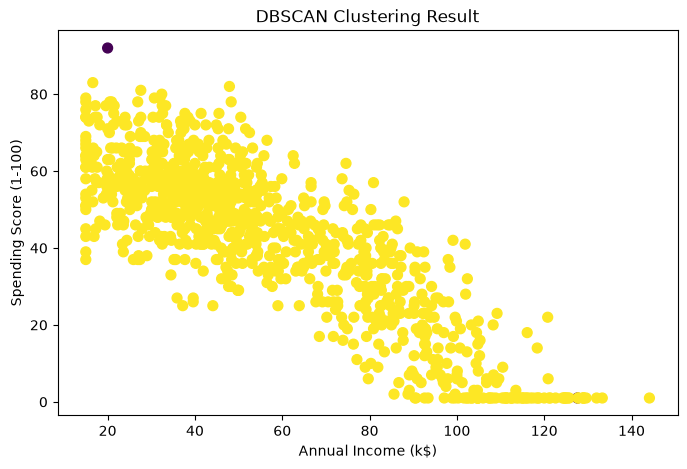

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    features["Annual Income (k$)"],
    features["Spending Score (1-100)"],
    c=dbscan_labels,
    s=50
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering Result")
plt.show()

<div style="
    background:#FFFFFF;
    border-left:3px solid #C7D2FE;
    padding:10px 13px;
    margin:8px 0 12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">How to Read the Plot:</b>
Points with the same color belong to the same DBSCAN cluster. Since the model detected only one cluster, most customers should appear as one main group. The few points with a different label represent the observations detected as noise.

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #6366F1;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h3 style="color:#4F46E5; margin:0 0 6px 0;">
Testing Different eps Values
</h3>

The first DBSCAN result produced only one cluster, so I will test a few smaller <b>eps</b> values. This helps check whether the current neighborhood distance is combining too many customers into the same dense region.

</div>

In [35]:
for eps in [0.2, 0.3, 0.4, 0.5]:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(scaled_features)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(
        "eps =", eps,
        "| Clusters:", clusters,
        "| Noise:", noise
    )

eps = 0.2 | Clusters: 14 | Noise: 221
eps = 0.3 | Clusters: 2 | Noise: 47
eps = 0.4 | Clusters: 1 | Noise: 9
eps = 0.5 | Clusters: 1 | Noise: 2


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Observation:</b>
The DBSCAN result changed clearly as the value of <b>eps</b> increased. With <b>eps = 0.2</b>, the data was divided into many small clusters and a large number of points were treated as noise. As <b>eps</b> increased, the clusters started to merge and the number of noise points decreased.

Among the tested values, <b>eps = 0.3</b> gives the most balanced result, producing <b>2 clusters</b> with <b>47 noise points</b>. Therefore, I will use this value for the final DBSCAN visualization.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
I will now run DBSCAN again using <b>eps = 0.3</b> and keep <b>min_samples = 5</b> to examine the selected clustering result.

</div>

In [36]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(scaled_features)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 47


<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
Now I will visualize the final DBSCAN result using the selected value <b>eps = 0.3</b>.  
The goal is to see how the customers were grouped and which points were identified as noise.

</div>

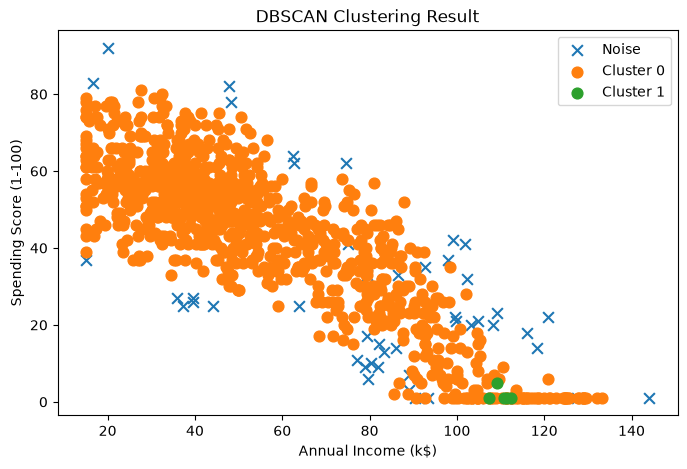

In [38]:
# Create a copy of the cleaned numeric data
dbscan_result = features.copy()

# Add the DBSCAN cluster labels
dbscan_result["DBSCAN_Cluster"] = dbscan_labels

# Plot the clustering result
plt.figure(figsize=(8, 5))

for cluster in sorted(dbscan_result["DBSCAN_Cluster"].unique()):
    
    cluster_data = dbscan_result[
        dbscan_result["DBSCAN_Cluster"] == cluster
    ]
    
    if cluster == -1:
        plt.scatter(
            cluster_data["Annual Income (k$)"],
            cluster_data["Spending Score (1-100)"],
            label="Noise",
            s=60,
            marker="x"
        )
    else:
        plt.scatter(
            cluster_data["Annual Income (k$)"],
            cluster_data["Spending Score (1-100)"],
            label=f"Cluster {cluster}",
            s=60
        )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering Result")
plt.legend()
plt.show()

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.55;
">

<b style="color:#4F46E5; font-size:17px;">
Reading the DBSCAN Map
</b>

<b>01 — The <span style="color:#FF7F0E;">orange</span> region</b><br>
Most customers were connected into one large cluster. The pattern stretches from lower-income customers with higher spending scores toward higher-income customers with lower spending scores.

<b>02 — The <span style="color:#2CA02C;">green</span> group</b><br>
A very small second cluster appears near the bottom-right of the plot. These customers have relatively high annual income but a spending score close to zero, so DBSCAN recognized them as a separate dense group.

<b>03 — The <span style="color:#1F77B4;">blue crosses</span></b><br>
These are the <b>47 noise points</b>. They are scattered outside the dense regions, so DBSCAN does not force them into either cluster.

<b style="color:#4F46E5;">So, what changed?</b><br>
K-Means described the customers using three complete groups. DBSCAN tells a different story: <b>one dominant cluster, one small high-income/low-spending cluster, and several isolated customers.</b>

This is exactly why comparing clustering methods matters: the same dataset can look very different depending on how the algorithm defines a group.

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 6px 0;
">
Step 2 — Hierarchical Clustering
</h3>

After seeing how DBSCAN groups the customers by density, I will now examine the same data using Hierarchical Clustering.

Instead of finding clusters all at once, this method gradually merges similar observations and builds a tree that shows how the groups are connected.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
I will use the <b>Ward</b> method to build the hierarchy. Ward merges groups in a way that tries to keep the points inside each cluster as similar as possible.

</div>

In [39]:
Z = linkage(
    scaled_features,
    method="ward"
)

<div style="
    background:#FFFFFF;
    border-left:3px solid #C7D2FE;
    padding:9px 13px;
    margin:8px 0 12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">What happened?</b>
The linkage matrix stores the order in which observations and groups are merged. We can now turn this information into a dendrogram and inspect the hierarchy visually.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
The dendrogram will help me decide where the tree can be cut to form meaningful customer clusters.

</div>

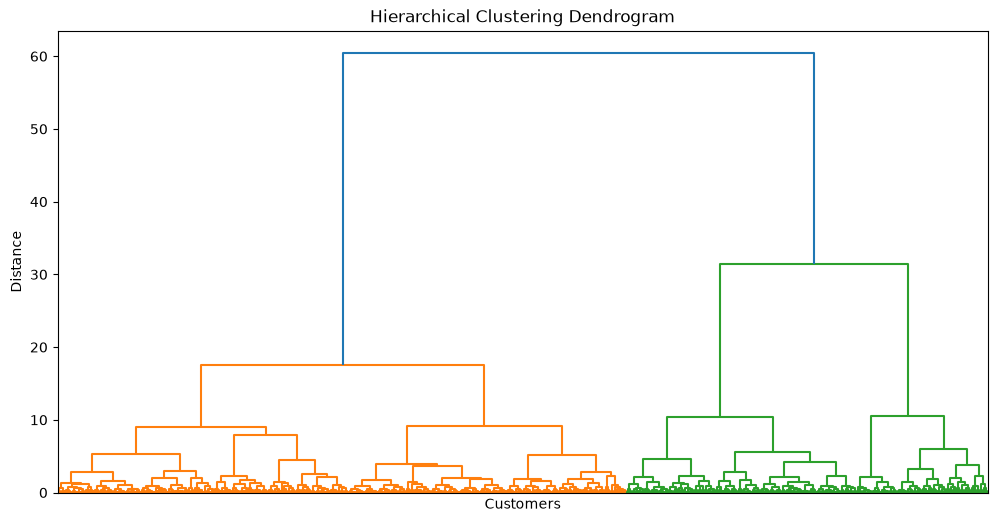

In [40]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    no_labels=True
)

plt.xlabel("Customers")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5; font-size:17px;">
Reading the Dendrogram
</b>

The dendrogram gives us a different way to discover the customer groups. Instead of choosing the number of clusters first, we look at the 
<b style="color:#4F46E5;">large vertical gaps</b> between merges.
The final two large branches do not join until a distance of about 
<b style="color:#4F46E5;">60</b>, while another important merge appears around 
<b style="color:#4F46E5;">31</b>.

If the tree is cut near a distance of 
<b style="color:#4F46E5;">25</b>, 
<b style="color:#4F46E5;">three separate branches</b> remain.

<b style="color:#4F46E5;">What does this suggest?</b><br>

The dendrogram points to 
<b style="color:#4F46E5;">3 possible customer clusters</b>. 
This is interesting because K-Means also found 
<b style="color:#4F46E5;">3 clusters</b> in Day 1, even though the two methods reached that result in very different ways.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
Now I will use the selected cut height of <b style="color:#4F46E5;">25</b> to turn the dendrogram branches into final cluster labels and count how many groups were formed.

</div>

In [41]:
hierarchical_labels = fcluster(
    Z,
    t=25,
    criterion="distance"
)

n_hierarchical_clusters = len(set(hierarchical_labels))

print("Number of hierarchical clusters:", n_hierarchical_clusters)

Number of hierarchical clusters: 3


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Observation:</b>
Cutting the dendrogram at a distance of <b style="color:#4F46E5;">25</b> produced <b style="color:#4F46E5;">3 hierarchical clusters</b>.

This is interesting because K-Means also produced <b style="color:#4F46E5;">3 clusters</b>, but the two methods reached that structure differently. K-Means starts with a fixed number of groups, while Hierarchical Clustering reveals the grouping gradually through the dendrogram.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
Now I will visualize the <b style="color:#4F46E5;">3 hierarchical clusters</b> using Annual Income and Spending Score so I can compare their shape with the DBSCAN result.

</div>

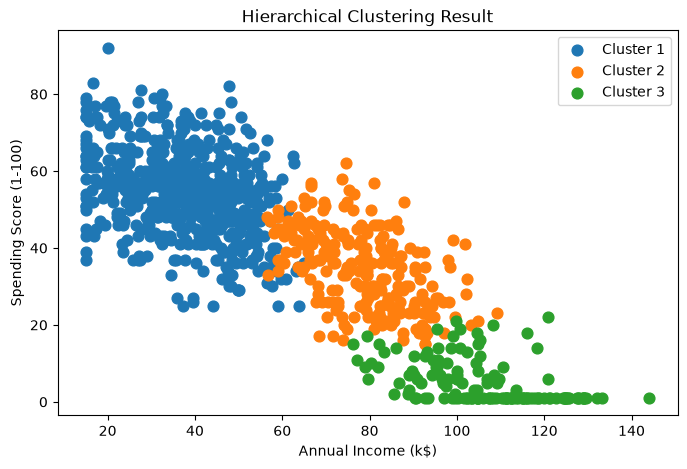

In [42]:
hierarchical_result = features.copy()

hierarchical_result["Hierarchical_Cluster"] = hierarchical_labels

plt.figure(figsize=(8, 5))

for cluster in sorted(
    hierarchical_result["Hierarchical_Cluster"].unique()
):
    cluster_data = hierarchical_result[
        hierarchical_result["Hierarchical_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        s=60
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering Result")
plt.legend()
plt.show()

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5; font-size:17px;">
Reading the Hierarchical Result
</b>

The hierarchical plot divides the customers into 
<b style="color:#4F46E5;">3 groups</b>, which matches the number suggested by the dendrogram.

Unlike DBSCAN, Hierarchical Clustering does not leave customers outside the groups as noise. Instead, every observation becomes part of one of the branches created by the hierarchy

<b style="color:#4F46E5;">What should we notice?</b><br>

DBSCAN described the data as 
<b style="color:#4F46E5;">2 dense groups + noise</b>, while Hierarchical Clustering produced 
<b style="color:#4F46E5;">3 complete groups</b>.

This already shows that the algorithms are not simply giving different colors to the same points. They are actually using different definitions of what a cluster should be.

</div>

In [45]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_features)

n_kmeans_clusters = len(set(kmeans_labels))

print("Number of K-Means clusters:", n_kmeans_clusters)

Number of K-Means clusters: 3


c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 6px 0;
">
Step 3 — Compare the Three Methods
</h3>

Now that all three clustering methods have been applied to the same customer data, I can compare how each one interprets the structure of the dataset.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
The comparison will focus on the number of clusters, noise detection, and how each method forms its groups.

</div>

In [47]:
comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Clusters": [
        3,  # Result from Day 1
        n_clusters,
        n_hierarchical_clusters
    ],
    "Noise Points": [
        0,
        n_noise,
        0
    ]
})

comparison

,Method,Clusters,Noise Points
0,K-Means,3,0
1,DBSCAN,2,47
2,Hierarchical,3,0


<div style="
    background:#FFFFFF;
    border-left:3px solid #C7D2FE;
    padding:9px 13px;
    margin:8px 0 12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Reading the Comparison:</b>
K-Means and Hierarchical Clustering both produced <b style="color:#4F46E5;">3 clusters</b>, while DBSCAN produced <b style="color:#4F46E5;">2 clusters</b> and identified <b style="color:#4F46E5;">47 noise points</b>.

The difference is not only in the numbers. Each method uses a different rule to decide what a cluster should look like.

</div>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:10px 14px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
">

<b style="color:#4F46E5;">Note:</b>
To make the comparison easier to read, I will visualize the number of clusters found by each method.

</div>

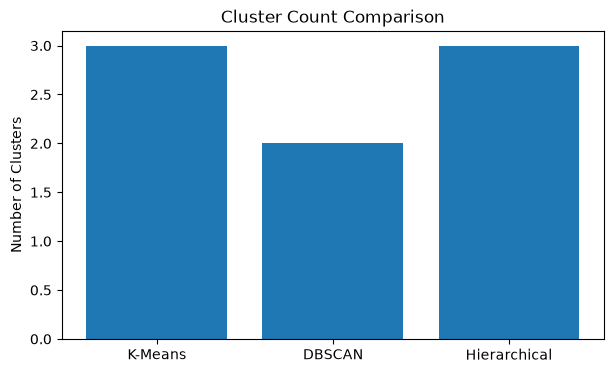

In [44]:
plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Method"],
    comparison["Clusters"]
)

plt.ylabel("Number of Clusters")
plt.title("Cluster Count Comparison")
plt.show()

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5; font-size:17px;">
One Dataset, Three Views
</b>

The chart shows an interesting split in the results. 
<b style="color:#4F46E5;">K-Means</b> and 
<b style="color:#4F46E5;">Hierarchical Clustering</b> both divide the customers into 
<b style="color:#4F46E5;">3 groups</b>, while 
<b style="color:#4F46E5;">DBSCAN</b> finds only 
<b style="color:#4F46E5;">2 dense groups</b>.

But the smaller DBSCAN count does not mean it found less information. It also identified 
<b style="color:#4F46E5;">47 customers as noise</b>, something the other two methods do not do.

<b style="color:#4F46E5;">The interesting part:</b>
Two algorithms can produce the same number of clusters without necessarily grouping the customers in exactly the same way.

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:14px 16px;
    margin:14px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 7px 0;
">
Step 4 — Choosing the Best Method
</h3>

The three algorithms have now looked at the same customer data from different perspectives. The final question is not simply which method produced more clusters, but which one gives the most useful description of the structure in this dataset.

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.55;
">

<h3 style="
    color:#4F46E5;
    margin:0 0 8px 0;
">
Final Decision
</h3>

 - For this customer dataset, <b style="color:#4F46E5;">K-Means</b> and 
<b style="color:#4F46E5;">Hierarchical Clustering</b> both support a structure of 
<b style="color:#4F46E5;">3 customer groups</b>.

- DBSCAN gives a different interpretation by finding 
<b style="color:#4F46E5;">2 dense clusters</b> and treating 
<b style="color:#4F46E5;">47 observations as noise</b>.

- Because the customer data forms broad, connected groups rather than clearly separated irregular shapes, 
<b style="color:#4F46E5;">K-Means gives the clearest overall segmentation</b> for this dataset.

- Hierarchical Clustering is also useful because the dendrogram shows how the groups are related, while DBSCAN is valuable for identifying customers that do not clearly belong to a dense region.

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0;
    font-family:'Trebuchet MS', Arial, sans-serif;
    color:#263238;
    line-height:1.5;
">

<b style="color:#4F46E5;">Day 2 Takeaway:</b>
There is no single clustering algorithm that is always best. K-Means, DBSCAN, and Hierarchical Clustering look at the same data in different ways, so the final choice should depend on the shape of the data, the presence of noise, and the goal of the analysis.

</div>